In [7]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt

### Setting detectors network

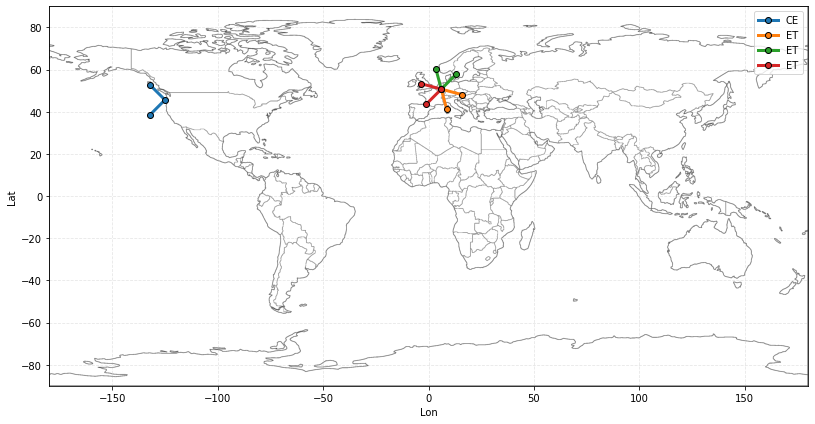

In [8]:
# Cosmic Explorer Coordinates
# https://cosmicexplorer.org/celocations.html
lon_CE = -125.0891
lat_CE = 45.64555

# Einstein Telecope Coordinates (Vaalserberg)
lon_ET = 6.02138
lat_ET = 50.75345

det_CE  = {'name':'CE','lon':lon_CE, 'lat':lat_CE, 'rot':-135, 'shape':90}
det_ET1 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':-120, 'shape':60}

detectors = [det_CE,det_ET1,det_ET2,det_ET3]
fig = gw.draw_detectors(detectors)

### Setting GW source parameters

In [9]:
# Binary of Neutron Stars (BNS)
m1 = 1.5 # Solar Mass
m2 = 1.4 # Solar Mass
M = m1+m2
eta = m1*m2/M**2
Mc = M*eta**(3./5)

GwPrms = {}
GwPrms['dL']       = 1.55 # Gpc
GwPrms['Mc']       = Mc
GwPrms['eta']      = eta
GwPrms['iota']     = np.pi/4 # radians
GwPrms['t_coal']   = 0.1    # seconds
GwPrms['phi_coal'] = np.pi/4 # radians
GwPrms["psi"]      = np.pi/4 # radians
GwPrms["RA"]       = 45. # degrees
GwPrms["Dec"]      = 30. # degrees

GwPrms["sx1"]  = 0.
GwPrms["sy1"]  = 0.
GwPrms["sz1"]  = 0.1

GwPrms["sx2"]  = 0.
GwPrms["sy2"]  = 0.
GwPrms["sz2"]  = -0.3

### Computing GW strains (detectors outputs)
$$h(f) = F_+h_+(f) + F_{\times}h_{\times}(f)$$

In [10]:
dF = 0.01 # sampling rate (frequency)

freq = np.arange(.1,300,dF)
print(f"Number of frequency points: {len(freq)}")

approx = "IMRPhenomD"

print("Computing waveforms jax ...")
H_dets_jax = gw.get_strain( detectors,
                            GwPrms,
                            freq,
                            approx,
                            enable_jax_waveforms=True,
                            disable_jit=True,
                            EarthRotation=True
                        )



print("Computing waveforms lal ...")
H_dets_lal = gw.get_strain( detectors,
                            GwPrms,
                            freq,
                            approx,
                            enable_jax_waveforms=False,
                            dF=dF,
                            EarthRotation=True
                        )


Number of frequency points: 29990
Computing waveforms jax ...
>> Disabling jax.jit()
Computing waveforms lal ...


In [11]:
# Auxiliar functions

Amplitude = lambda x: np.real( np.sqrt(x*np.conj(x)) )
Phase = lambda x: np.unwrap(np.angle(x))/np.pi

### Plotting signals (Comparing JAX vs LAL)

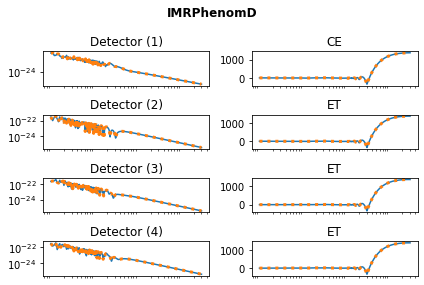

In [12]:
Ndets = len(detectors)
plt.suptitle(approx,weight="bold")
for i in range(Ndets):
    h1 = H_dets_jax[i]
    h2 = H_dets_jax[i]

    A1 = Amplitude(h1)
    A2 = Amplitude(h2)

    Phase1 = Phase(h1)
    Phase2 = Phase(h2)

    plt.subplot(Ndets,2,2*i+1)
    plt.title(f"Detector ({i+1})")
    plt.loglog(freq,A1)
    plt.loglog(freq,A2,':',lw=3)
    plt.xticks([])

    plt.subplot(Ndets,2,2*i+2)
    plt.title(detectors[i]['name'])
    plt.plot(freq,Phase1)
    plt.plot(freq,Phase2,':',lw=3)
    plt.xscale('log')
    plt.xticks([])
plt.tight_layout()